# Feature Comparison for Classification

This notebook compares feature families from the `spafe` Python extension on a small audio classification task. It intentionally avoids scikit-learn: dataset generation, feature summarization, standardization, PCA projection, and nearest-centroid classification are implemented with NumPy so the workflow is transparent and lightweight.

> Run from an environment where the local extension is installed:
>
> ```bash
> python -m pip install maturin notebook matplotlib numpy
> maturin develop
> jupyter notebook notebooks
> ```

In [1]:
from __future__ import annotations

import math
from collections import Counter
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
import spafe

## Build a Small Labeled Dataset

The classes are synthetic but intentionally different in spectral content. Each sample adds small deterministic variation in frequency, amplitude, harmonic balance, and phase.

In [2]:
fs = 8_000
seconds = 0.45
classes = {
    "low": 180.0,
    "mid": 420.0,
    "high": 980.0,
}


def make_sample(base_freq: float, idx: int) -> list[float]:
    samples = int(seconds * fs)
    freq = base_freq * (1.0 + 0.015 * ((idx % 5) - 2))
    phase = 0.37 * idx
    harmonic = 2.0 * freq
    mod_freq = 3.0 + (idx % 4)
    signal = []
    for n in range(samples):
        t = n / fs
        envelope = 0.65 + 0.20 * math.sin(2.0 * math.pi * mod_freq * t + phase)
        value = envelope * math.sin(2.0 * math.pi * freq * t + phase)
        value += 0.22 * math.sin(2.0 * math.pi * harmonic * t + phase / 2.0)
        value += 0.04 * math.sin(2.0 * math.pi * (freq + 37.0) * t)
        signal.append(value)
    return signal


samples: list[list[float]] = []
labels: list[str] = []
sample_ids: list[int] = []
for label, base_freq in classes.items():
    for idx in range(10):
        samples.append(make_sample(base_freq, idx))
        labels.append(label)
        sample_ids.append(idx)

print(f"samples={len(samples)}, class counts={Counter(labels)}")

samples=30, class counts=Counter({'low': 10, 'mid': 10, 'high': 10})


## Train/Test Split

A deterministic split keeps the notebook reproducible. Every fourth example per class is held out for testing.

In [3]:
train_idx = [idx for idx, sample_id in enumerate(sample_ids) if sample_id % 4 != 0]
test_idx = [idx for idx, sample_id in enumerate(sample_ids) if sample_id % 4 == 0]

y = np.asarray(labels)
y_train = y[train_idx]
y_test = y[test_idx]
print(f"train={len(train_idx)}, test={len(test_idx)}")
print("test class counts", Counter(y_test))

train=21, test=9
test class counts Counter({np.str_('low'): 3, np.str_('mid'): 3, np.str_('high'): 3})


## Feature Extraction and Summaries

Most classifiers expect fixed-length vectors. For each frame-by-coefficient matrix, this notebook uses the per-coefficient mean and standard deviation across frames.

In [4]:
feature_opts = spafe.FeatureOptions(
    fs=fs,
    nfft=256,
    nfilts=20,
    num_ceps=13,
    win_len=0.025,
    win_hop=0.010,
    normalize="mean_subtraction",
)
cqcc_opts = spafe.CqccOptions(number_of_octaves=4, number_of_bins_per_octave=12)


def summarize_matrix(matrix: list[list[float]]) -> np.ndarray:
    arr = np.asarray(matrix, dtype=np.float64)
    return np.concatenate([arr.mean(axis=0), arr.std(axis=0)])


def spectral_summary(signal: list[float]) -> np.ndarray:
    feats = spafe.extract_feats(signal, fs, nfft=512)
    spread = np.asarray(feats.spectral_spread, dtype=np.float64)
    return np.asarray(
        [
            feats.spectral_centroid,
            feats.spectral_skewness,
            feats.spectral_kurtosis,
            feats.spectral_entropy,
            feats.spectral_flatness,
            feats.spectral_flux,
            feats.spectral_std,
            feats.spectral_variance,
            spread.mean(),
            spread.std(),
        ],
        dtype=np.float64,
    )


extractors: dict[str, Callable[[list[float]], np.ndarray]] = {
    "MFCC": lambda sig: summarize_matrix(spafe.mfcc(sig, feature_opts)),
    "GFCC": lambda sig: summarize_matrix(spafe.gfcc(sig, feature_opts)),
    "PNCC": lambda sig: summarize_matrix(spafe.pncc(sig, feature_opts)),
    "CQCC": lambda sig: summarize_matrix(spafe.cqcc(sig, feature_opts, cqcc_opts)),
    "Spectral": spectral_summary,
}

feature_tables: dict[str, np.ndarray] = {}
for name, extractor in extractors.items():
    feature_tables[name] = np.vstack([extractor(signal) for signal in samples])
    print(f"{name:8s}", feature_tables[name].shape)

MFCC     (30, 26)
GFCC     (30, 26)
PNCC     (30, 26)
CQCC     (30, 26)
Spectral (30, 10)


## A Tiny Classifier

Nearest-centroid classification is simple: standardize features using training statistics, compute one centroid per class, then assign each test vector to the closest centroid.

In [5]:
def standardize(train: np.ndarray, test: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mean = train.mean(axis=0)
    std = train.std(axis=0)
    std[std == 0.0] = 1.0
    return (train - mean) / std, (test - mean) / std


def nearest_centroid_predict(x_train: np.ndarray, y_train: np.ndarray, x_test: np.ndarray) -> np.ndarray:
    unique = np.unique(y_train)
    centroids = np.vstack([x_train[y_train == label].mean(axis=0) for label in unique])
    distances = ((x_test[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    return unique[distances.argmin(axis=1)]


def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, class_order: list[str]) -> np.ndarray:
    index = {label: idx for idx, label in enumerate(class_order)}
    matrix = np.zeros((len(class_order), len(class_order)), dtype=int)
    for truth, pred in zip(y_true, y_pred):
        matrix[index[truth], index[pred]] += 1
    return matrix


class_order = list(classes.keys())
results = []
predictions: dict[str, np.ndarray] = {}
standardized_tables: dict[str, np.ndarray] = {}
for name, table in feature_tables.items():
    x_train, x_test = standardize(table[train_idx], table[test_idx])
    y_pred = nearest_centroid_predict(x_train, y_train, x_test)
    accuracy = float((y_pred == y_test).mean())
    predictions[name] = y_pred
    standardized_tables[name] = np.vstack([x_train, x_test])
    results.append((name, accuracy, confusion_matrix(y_test, y_pred, class_order)))

for name, accuracy, matrix in results:
    print(f"{name:8s} accuracy={accuracy:.3f}")
    print(matrix)

MFCC     accuracy=1.000
[[3 0 0]
 [0 3 0]
 [0 0 3]]
GFCC     accuracy=1.000
[[3 0 0]
 [0 3 0]
 [0 0 3]]
PNCC     accuracy=1.000
[[3 0 0]
 [0 3 0]
 [0 0 3]]
CQCC     accuracy=1.000
[[3 0 0]
 [0 3 0]
 [0 0 3]]
Spectral accuracy=0.667
[[1 2 0]
 [0 2 1]
 [0 0 3]]


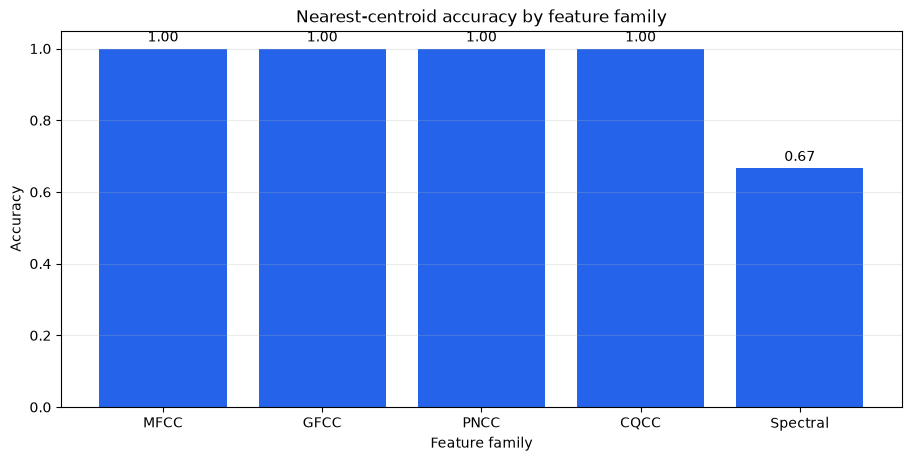

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
names = [name for name, _, _ in results]
accuracies = [accuracy for _, accuracy, _ in results]
ax.bar(names, accuracies, color="#2563eb")
ax.set_ylim(0.0, 1.05)
ax.set_title("Nearest-centroid accuracy by feature family")
ax.set_xlabel("Feature family")
ax.set_ylabel("Accuracy")
ax.grid(True, axis="y", alpha=0.25)
for idx, value in enumerate(accuracies):
    ax.text(idx, value + 0.02, f"{value:.2f}", ha="center")
plt.show()

## PCA Projections

PCA is implemented directly with SVD. These plots show how separable the classes look after reducing each feature family to two dimensions.

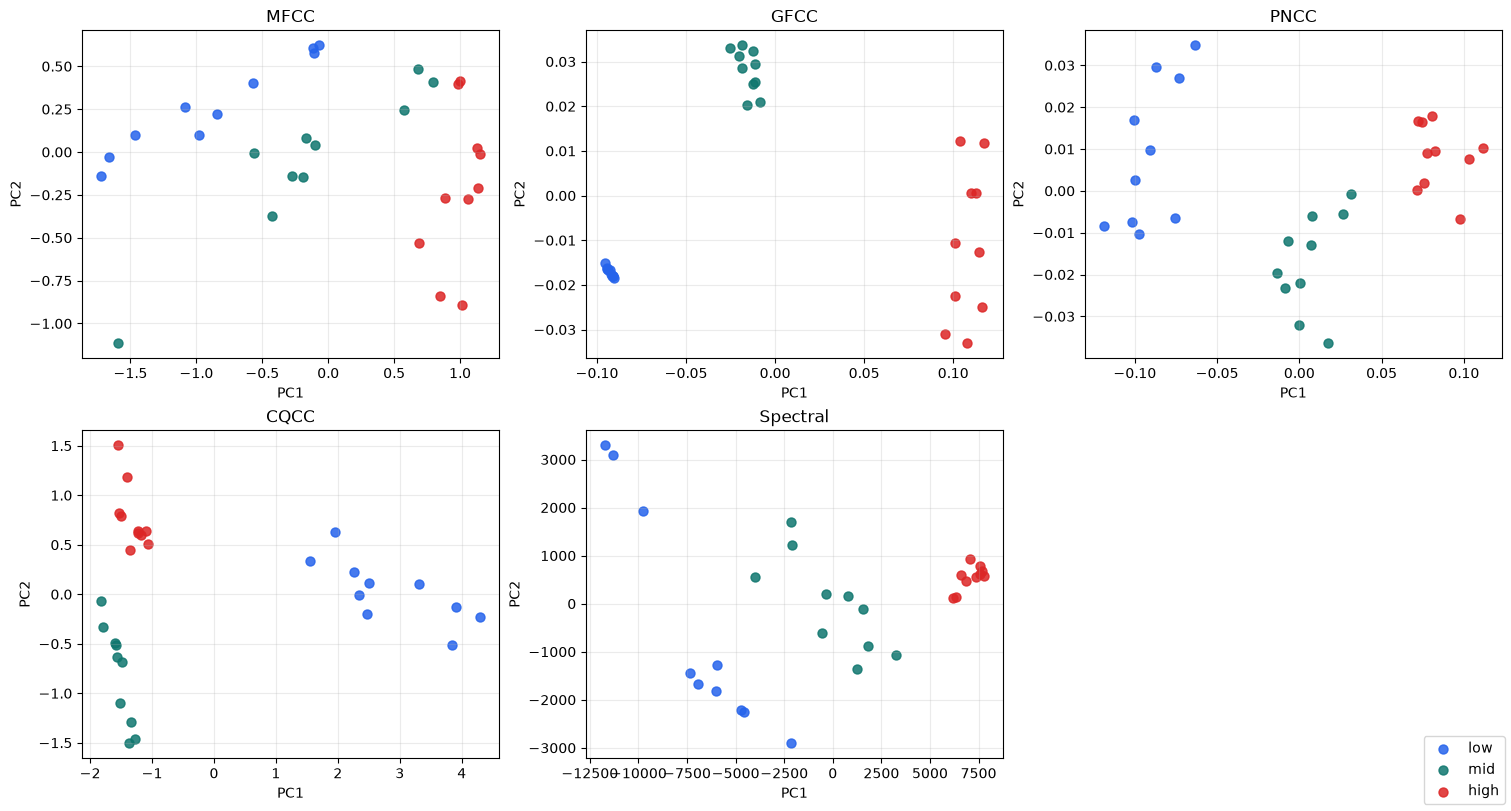

In [7]:
def pca2(table: np.ndarray) -> np.ndarray:
    centered = table - table.mean(axis=0)
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    return centered @ vt[:2].T


colors = {"low": "#2563eb", "mid": "#0f766e", "high": "#dc2626"}
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for ax, (name, table) in zip(axes.ravel(), feature_tables.items()):
    projection = pca2(table)
    for label in class_order:
        mask = y == label
        ax.scatter(
            projection[mask, 0],
            projection[mask, 1],
            label=label,
            color=colors[label],
            s=42,
            alpha=0.85,
        )
    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.25)
axes.ravel()[-1].axis("off")
handles, labels_for_legend = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels_for_legend, loc="lower right")
plt.show()

## Confusion Matrix Plot

The confusion matrix helps identify which classes a feature family confuses. Change `feature_to_inspect` to compare families.

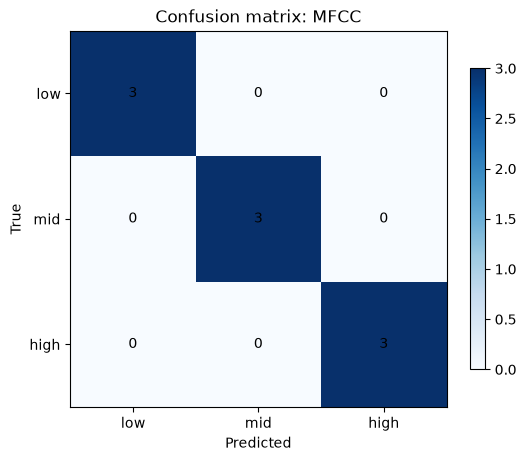

In [8]:
feature_to_inspect = max(results, key=lambda item: item[1])[0]
matrix = next(matrix for name, _, matrix in results if name == feature_to_inspect)

fig, ax = plt.subplots(figsize=(5.5, 4.5), constrained_layout=True)
image = ax.imshow(matrix, cmap="Blues")
ax.set_title(f"Confusion matrix: {feature_to_inspect}")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(len(class_order)), class_order)
ax.set_yticks(range(len(class_order)), class_order)
for row in range(matrix.shape[0]):
    for col in range(matrix.shape[1]):
        ax.text(col, row, str(matrix[row, col]), ha="center", va="center", color="black")
fig.colorbar(image, ax=ax, shrink=0.8)
plt.show()

## What to Try Next

- Replace synthetic signals with real labeled audio clips.
- Export `feature_tables` with the export workflow notebook.
- Try different summary statistics: median, percentiles, energy, or deltas.
- Build a train/test split by speaker or recording session for real data.
- If you want full ML tooling, feed these feature matrices into scikit-learn, PyTorch, or another classifier stack.